In [1]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# --- Load DICOM Series ---
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames("../data/processed/006/left")
reader.SetFileNames(dicom_names)
volume = reader.Execute()

ImageSeriesReader (0x7fcb28705380): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.398674



In [7]:
# Convert to numpy array: shape = (slices, height, width) = (Z, Y, X)
ct_array = sitk.GetArrayFromImage(volume)
print("CT shape:", ct_array.shape)


CT shape: (300, 512, 256)


In [16]:
ct_array

array([[[-1024, -1024, -1024, ..., -1017,  -994, -1016],
        [-1024, -1024, -1024, ...,  -989,  -955, -1024],
        [-1024, -1024, -1024, ..., -1024,  -981, -1007],
        ...,
        [-1024, -1024, -1024, ..., -1016,  -994, -1011],
        [-1024, -1024, -1024, ..., -1021,  -992,  -990],
        [-1024, -1024, -1024, ...,  -981, -1024,  -991]],

       [[-1024, -1024, -1024, ..., -1024,  -987, -1024],
        [-1024, -1024, -1024, ..., -1002,  -953, -1001],
        [-1024, -1024, -1024, ..., -1024, -1010,  -989],
        ...,
        [-1024, -1024, -1024, ..., -1007, -1014, -1009],
        [-1024, -1024, -1024, ..., -1024,  -971, -1001],
        [-1024, -1024, -1024, ..., -1006,  -993, -1008]],

       [[-1024, -1024, -1024, ..., -1024,  -963, -1024],
        [-1024, -1024, -1024, ..., -1024,  -953, -1007],
        [-1024, -1024, -1024, ..., -1024, -1001, -1012],
        ...,
        [-1024, -1024, -1024, ..., -1001, -1024, -1012],
        [-1024, -1024, -1024, ...,  -992,  -9

In [8]:
import numpy as np

def simulate_realistic_knee_drr(ct_volume, axis=1, hu_window=(-300, 1000), gamma=1.0, normalize_output=True):
    """
    Simulate a realistic Digitally Reconstructed Radiograph (DRR) from a 3D CT volume.

    Parameters:
    - ct_volume: 3D NumPy array of CT data (in HU).
    - axis: int, projection direction axis along which to sum (e.g., 0, 1, or 2).
            Commonly: 1 = AP view, 2 = lateral view.
    - hu_window: tuple (min_HU, max_HU) specifying clipping window for HU values.
                 Typical values for knee: (-300, 1000).
    - gamma: float, gamma correction factor to enhance image realism (default 1.0 means no correction).
    - normalize_output: bool, whether to normalize output to [0, 1].

    Returns:
    - 2D NumPy array (float32) representing the DRR image, scaled between 0 and 1 (if normalized).
    """

    hu_min, hu_max = hu_window

    # 1. Clip HU values to the window to remove outliers and focus on relevant tissues
    ct_clipped = np.clip(ct_volume, hu_min, hu_max)

    # 2. Normalize clipped HU values to [0, 1] range representing linear attenuation coefficients
    mu = (ct_clipped - hu_min) / (hu_max - hu_min)

    # 3. Project volume by summing linear attenuation along the projection axis
    #    Cast to float32 for memory and computation efficiency
    projection = np.mean(mu.astype(np.float32), axis=axis)

    # 4. Simulate X-ray attenuation using exponential decay (Beer-Lambert law)
    drr = np.exp(-projection)

    # 5. Invert image intensity: denser materials attenuate more (darker), so invert for X-ray style (bright = dense)
    drr = 1.0 - drr

    # 6. Normalize to [0, 1] if requested
    if normalize_output:
        drr = (drr - drr.min()) / (drr.max() - drr.min() + 1e-12)  # Added tighter epsilon for stability

    # 7. Apply gamma correction if gamma != 1
    if gamma != 1.0:
        drr = np.power(drr, gamma)

    return drr.astype(np.float32)


DRR image shape: (300, 512)


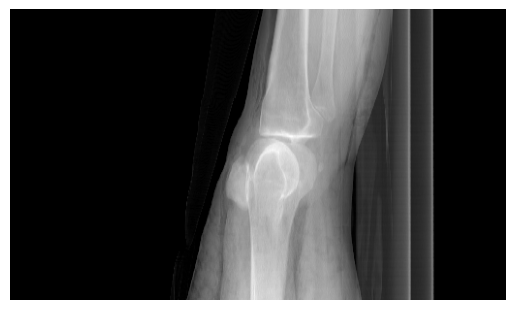

In [15]:
drr_image = simulate_realistic_knee_drr(ct_array, hu_window= (-300, 1000),axis=2, gamma=0.7)

print("DRR image shape:", drr_image.shape)

plt.imshow(drr_image, cmap='gray')
plt.axis('off')
plt.show()
plt.imsave('../data/processed/002/right.png', drr_image, cmap='gray')

In [83]:
print("DRR stats: min =", drr_image.min(), ", max =", drr_image.max(), ", mean =", drr_image.mean())


DRR stats: min = 0.0 , max = 0.99999297 , mean = 0.80054617


In [ ]:
from skimage import exposure

# After getting drr_image (0 to 1 float)
drr_eq = exposure.equalize_adapthist(drr_image, clip_limit=0.03)
plt.imshow(drr_eq, cmap='gray')
plt.title("Contrast Enhanced DRR")
plt.axis('off')
plt.show()


In [5]:
print("CT Volume stats:", np.min(ct_array), np.max(ct_array), np.mean(ct_array))

CT Volume stats: -1024 1769 -887.7433252716064
